In [ ]:
from google.colab import drive
from google.colab import files

# 1. 내 구글 드라이브 연동 (결과물을 저장하기 위함)
drive.mount('/content/drive')

# 2. 캐글 API 토큰(kaggle.json) 업로드
print("캐글에서 다운받은 kaggle.json 파일을 업로드해주세요.")
files.upload()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
캐글에서 다운받은 kaggle.json 파일을 업로드해주세요.


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"wichaeeun","key":"e2cacfacf987bce86b416e51bdb52d43"}'}

In [ ]:
# 캐글 폴더 세팅 및 권한 부여
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Yelp 데이터셋 다운로드 (약 1~2분 소요)
!kaggle datasets download -d yelp-dataset/yelp-dataset

# 코랩 임시 공간에 압축 풀기 (드라이브에 푸는 것보다 수십 배 빠름)
!unzip -q yelp-dataset.zip -d /content/yelp_data
print("데이터 다운로드 및 압축 해제 완료!")

Dataset URL: https://www.kaggle.com/datasets/yelp-dataset/yelp-dataset
License(s): other
100% 4.07G/4.07G [00:33<00:00, 130MB/s] 

데이터 다운로드 및 압축 해제 완료!


In [ ]:
import pandas as pd

# 비즈니스 데이터 불러오기
biz_path = '/content/yelp_data/yelp_academic_dataset_business.json'
biz_df = pd.read_json(biz_path, lines=True)

# 'Restaurants' 카테고리 필터링 (결측치 처리 포함)
biz_df = biz_df[biz_df['categories'].fillna('').str.contains('Restaurants')]

# 필라델피아 도시 필터링
target_city = 'Philadelphia'
biz_city = biz_df[biz_df['city'] == target_city]

# 추출할 식당들의 고유 ID 리스트 확보
target_biz_ids = set(biz_city['business_id'].tolist()) # 검색 속도를 위해 set으로 변환
print(f"{target_city} 내 타겟 식당 개수: {len(target_biz_ids)}개")

Philadelphia 내 타겟 식당 개수: 5852개


In [ ]:
review_path = '/content/yelp_data/yelp_academic_dataset_review.json'
chunk_size = 100000
review_chunks = []

print("리뷰 데이터 청크 필터링 시작... (약 3~5분 소요 예상)")

# 10만 줄씩 잘라서 읽기
for chunk in pd.read_json(review_path, lines=True, chunksize=chunk_size):
    # 타겟 식당 ID에 해당하는 리뷰만 남기기
    filtered_chunk = chunk[chunk['business_id'].isin(target_biz_ids)]
    review_chunks.append(filtered_chunk)

# 모아둔 조각들을 하나의 데이터프레임으로 병합
review_subset = pd.concat(review_chunks, ignore_index=True)
print(f"필터링된 총 리뷰 개수: {len(review_subset)}개")

리뷰 데이터 청크 필터링 시작... (약 3~5분 소요 예상)
필터링된 총 리뷰 개수: 687289개


In [ ]:
# 1. 3점 리뷰(중립) 제거
review_subset = review_subset[review_subset['stars'] != 3]

# 2. 4~5점은 1(긍정), 1~2점은 0(부정)으로 매핑
review_subset['is_positive'] = review_subset['stars'].apply(lambda x: 1 if x > 3 else 0)

# 3. 15,000개 무작위 샘플링 (10,000개 이상 요건 충족)
final_dataset = review_subset.sample(n=15000, random_state=42)

print("최종 샘플링 데이터 크기:", final_dataset.shape)
display(final_dataset.head(3))

최종 샘플링 데이터 크기: (15000, 10)


,review_id,user_id,business_id,stars,useful,funny,cool,text,date,is_positive
54652,yrgcQRzGdvODnmPgGzsLPg,8Oj4m1xxNoI1P_1mek9fQQ,QWqKTWQ2OiDgo3dzNkpung,5,3,0,1,After hearing rumors of delicious Soft Tofu pl...,2010-08-18 18:20:37,1
625097,QxtMgdD8Pz0w7XAUIPi3lg,KXYRjdlgg-Gw7mwF22ZAJg,0h4Oo6W8mG4HEYQzZRkoOA,4,0,0,1,Tasty new location in a plaza full of vietname...,2017-05-29 20:31:01,1
27548,gl3C_xngo9dUwJVz0lC2sw,gOAvWocRyGbKvUaitVy8fQ,nP4LqTcK1USiw5WnbOjW7A,5,0,0,0,"i ADMIT, I COME OFTEN: because all the food h...",2010-12-11 02:27:30,1


In [ ]:
# 내 구글 드라이브의 원하는 경로 지정 (예: Colab Notebooks 폴더)
save_path = '/content/drive/MyDrive/ml_project/Team-6/data/interim/yelp_subset_philly_15k.csv'

# CSV 파일로 영구 저장
final_dataset.to_csv(save_path, index=False)

print(f"저장 완료! 경로: {save_path}")
print("이제 코랩 세션이 초기화되어도 구글 드라이브에서 이 파일만 바로 불러와서 전처리를 이어갈 수 있습니다.")

저장 완료! 경로: /content/drive/MyDrive/ml_project/Team-6/data/interim/yelp_subset_philly_15k.csv
이제 코랩 세션이 초기화되어도 구글 드라이브에서 이 파일만 바로 불러와서 전처리를 이어갈 수 있습니다.


In [ ]:
import pandas as pd

# 비즈니스 데이터 불러오기
biz_path = '/content/yelp_data/yelp_academic_dataset_business.json'
biz_df = pd.read_json(biz_path, lines=True)

# 'Restaurants' 카테고리 필터링 (결측치 처리 포함)
biz_df = biz_df[biz_df['categories'].fillna('').str.contains('Restaurants')]

# 투손(Tucson) 도시 필터링 적용
target_city = 'Tucson'
biz_city = biz_df[biz_df['city'] == target_city]

# 추출할 식당들의 고유 ID 리스트 확보
target_biz_ids = set(biz_city['business_id'].tolist())
print(f"{target_city} 내 타겟 식당 개수: {len(target_biz_ids)}개")

Tucson 내 타겟 식당 개수: 2466개


In [ ]:
review_path = '/content/yelp_data/yelp_academic_dataset_review.json'
chunk_size = 100000
review_chunks = []

print(f"{target_city} 리뷰 데이터 청크 필터링 시작... (약 3~5분 소요 예상)")

# 10만 줄씩 잘라서 읽기
for chunk in pd.read_json(review_path, lines=True, chunksize=chunk_size):
    # 타겟 식당 ID에 해당하는 리뷰만 남기기
    filtered_chunk = chunk[chunk['business_id'].isin(target_biz_ids)]
    review_chunks.append(filtered_chunk)

# 모아둔 조각들을 하나의 데이터프레임으로 병합
review_subset = pd.concat(review_chunks, ignore_index=True)
print(f"필터링된 총 리뷰 개수: {len(review_subset)}개")

Tucson 리뷰 데이터 청크 필터링 시작... (약 3~5분 소요 예상)
필터링된 총 리뷰 개수: 249588개


In [ ]:
# 1. 3점 리뷰(중립) 제거
review_subset = review_subset[review_subset['stars'] != 3]

# 2. 4~5점은 1(긍정), 1~2점은 0(부정)으로 매핑
review_subset['is_positive'] = review_subset['stars'].apply(lambda x: 1 if x > 3 else 0)

# 3. 15,000개 무작위 샘플링
final_dataset = review_subset.sample(n=15000, random_state=42)

print("최종 샘플링 데이터 크기:", final_dataset.shape)

display(final_dataset.head(3))

최종 샘플링 데이터 크기: (15000, 10)


,review_id,user_id,business_id,stars,useful,funny,cool,text,date,is_positive
159675,-mqCkxEbdoSsteq0cku56w,4PFwh5zbgyPhTGRtxkSZZA,h8TJV8clolcjqp9aFV4OjQ,5,0,0,3,"Great Choriza and Eggs. I added jalapeños, and...",2013-12-15 19:16:48,1
63479,sJy0ukIauWf1crK4mIN6Og,ya8PYKqdqdhzHUBmw0_BBw,l7FBm3yxW0dx0WqQVlcQ1Q,4,0,0,0,All I have tried was the medium sauce wings 12...,2019-09-02 04:11:45,1
238203,-EJQgzb4hh5iAUyR8idcgQ,gBA3jN5d9UhL8LFJEGhx7w,JFteGsQlrJeJjur6cA1RhA,5,0,0,0,This place is awesome. Great environment. BY...,2019-03-02 01:09:10,1


In [ ]:
# 내 구글 드라이브의 원하는 경로 지정 (Tucson 파일명 적용)
save_path = '/content/drive/MyDrive/ml_project/Team-6/data/interim/yelp_subset_tucson_15k.csv'

# CSV 파일로 영구 저장
final_dataset.to_csv(save_path, index=False)

print(f"저장 완료! 경로: {save_path}")
print("이제 투손 지역의 15,000개 리뷰 데이터를 바탕으로 전처리 및 분석을 시작할 수 있습니다.")

저장 완료! 경로: /content/drive/MyDrive/ml_project/Team-6/data/interim/yelp_subset_tucson_15k.csv
이제 투손 지역의 15,000개 리뷰 데이터를 바탕으로 전처리 및 분석을 시작할 수 있습니다.


In [ ]:
import pandas as pd

# 비즈니스 데이터 불러오기
biz_path = '/content/yelp_data/yelp_academic_dataset_business.json'
biz_df = pd.read_json(biz_path, lines=True)

# 'Restaurants' 카테고리 필터링 (결측치 처리 포함)
biz_df = biz_df[biz_df['categories'].fillna('').str.contains('Restaurants')]

# 뉴올리언스(New Orleans) 도시 필터링 적용
target_city = 'New Orleans'
biz_city = biz_df[biz_df['city'] == target_city]

# 추출할 식당들의 고유 ID 리스트 확보
target_biz_ids = set(biz_city['business_id'].tolist())
print(f"{target_city} 내 타겟 식당 개수: {len(target_biz_ids)}개")

New Orleans 내 타겟 식당 개수: 2259개


In [ ]:
review_path = '/content/yelp_data/yelp_academic_dataset_review.json'
chunk_size = 100000
review_chunks = []

print(f"{target_city} 리뷰 데이터 청크 필터링 시작... (약 3~5분 소요 예상)")

# 10만 줄씩 잘라서 읽기
for chunk in pd.read_json(review_path, lines=True, chunksize=chunk_size):
    # 타겟 식당 ID에 해당하는 리뷰만 남기기
    filtered_chunk = chunk[chunk['business_id'].isin(target_biz_ids)]
    review_chunks.append(filtered_chunk)

# 모아둔 조각들을 하나의 데이터프레임으로 병합
review_subset = pd.concat(review_chunks, ignore_index=True)
print(f"필터링된 총 리뷰 개수: {len(review_subset)}개")

New Orleans 리뷰 데이터 청크 필터링 시작... (약 3~5분 소요 예상)
필터링된 총 리뷰 개수: 476421개


In [ ]:
# 1. 3점 리뷰(중립) 제거
review_subset = review_subset[review_subset['stars'] != 3]

# 2. 4~5점은 1(긍정), 1~2점은 0(부정)으로 매핑
review_subset['is_positive'] = review_subset['stars'].apply(lambda x: 1 if x > 3 else 0)

# 3. 15,000개 무작위 샘플링
final_dataset = review_subset.sample(n=15000, random_state=42)

print("최종 샘플링 데이터 크기:", final_dataset.shape)
display(final_dataset.head(3))

최종 샘플링 데이터 크기: (15000, 10)


,review_id,user_id,business_id,stars,useful,funny,cool,text,date,is_positive
436515,_QErwlNwmJ9womgJ1riRtg,uIvd7sTgGnzroU-Q3Xw63Q,SI3q166YxgbxzQxMfpiWjQ,5,2,1,1,Never in my 19 years have I tasted such a deli...,2015-05-16 19:21:44,1
24780,8BSfdkv-6pOfFjV_fTWLqw,0tJc82KWKivsvFlbuC3Gog,G9JqaURDTC_pSzji0bytwA,1,0,0,0,I ordered 2 burgers and a baked potato to go a...,2017-11-14 19:52:15,0
265918,CUAJTrqlP3R0SV0woGY6Rw,3Ua5WaJIO9yN3krBEVQFtA,103cmgKE0n1Cb8QCEXvbQQ,5,1,1,1,"The food was awesome, the drinks were superb, ...",2016-08-12 14:37:31,1


In [ ]:
# 내 구글 드라이브의 원하는 경로 지정 (New Orleans 파일명 적용)
save_path = '/content/drive/MyDrive/ml_project/Team-6/data/interim/yelp_subset_new_orleans_15k.csv'

# CSV 파일로 영구 저장
final_dataset.to_csv(save_path, index=False)

print(f"저장 완료! 경로: {save_path}")
print("이제 뉴올리언스 지역의 15,000개 리뷰 데이터를 바탕으로 밀도 높은 상권 전처리 및 분석을 시작할 수 있습니다.")

저장 완료! 경로: /content/drive/MyDrive/ml_project/Team-6/data/interim/yelp_subset_new_orleans_15k.csv
이제 뉴올리언스 지역의 15,000개 리뷰 데이터를 바탕으로 밀도 높은 상권 전처리 및 분석을 시작할 수 있습니다.


In [ ]:
# 1. 코랩 리눅스 시스템에 나눔 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 2. 설치된 폰트를 Matplotlib의 기본 폰트로 설정
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

# 3. 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("폰트 설치 및 설정이 완료되었습니다!")
print("★ 중요: 바로 위 상단 메뉴에서 [런타임] > [세션 다시 시작]을 꼭 한 번 눌러주세요! ★")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (36.5 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118252 files and direct

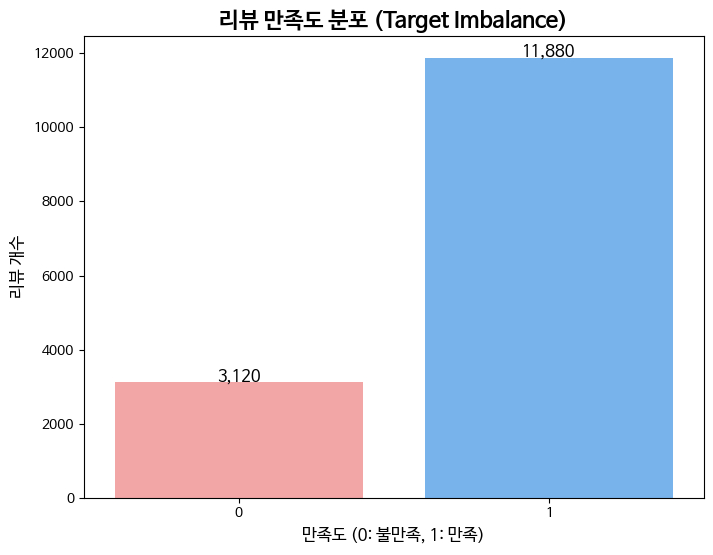

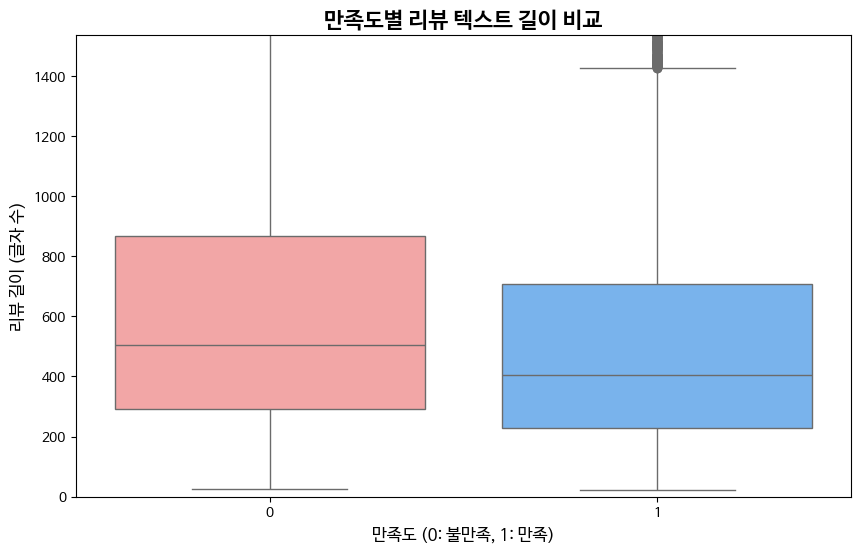

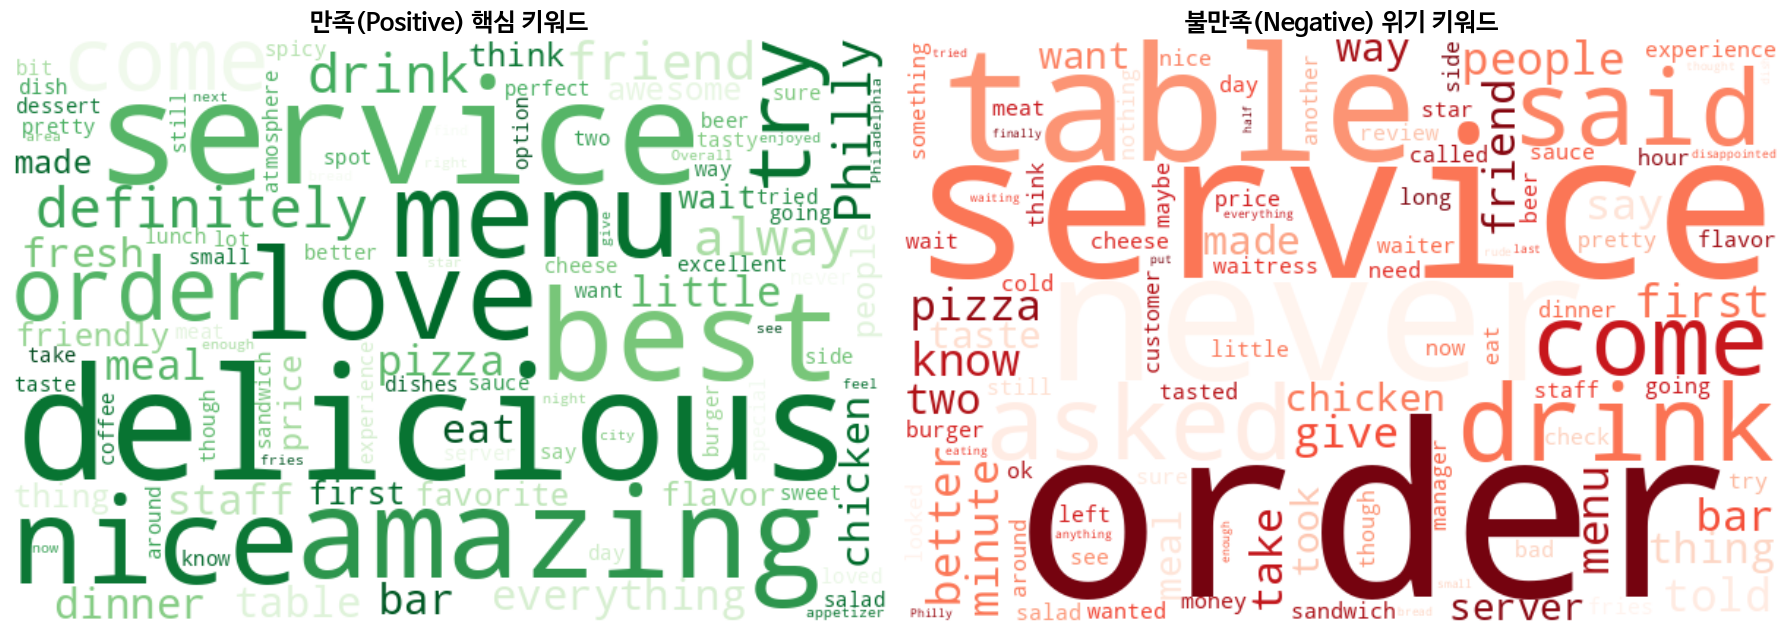

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

# ==========================================
# 1. 코랩 전용 한글 폰트 강제 지정
# ==========================================
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 (앞서 바로가기 만든 경로)
file_path = '/content/drive/MyDrive/ml_project/Team-6/data/interim/yelp_subset_philly_15k.csv'
df = pd.read_csv(file_path)
df['text_length'] = df['text'].astype(str).apply(len)


# ==========================================
# 2. Target 분포도 (FutureWarning 해결 버전)
# ==========================================
plt.figure(figsize=(8, 6))

# x를 hue에 그대로 배정하고 legend=False를 주면 최신 버전 경고가 사라집니다.
ax = sns.countplot(data=df, x='is_positive', hue='is_positive', palette=['#ff9999', '#66b3ff'], legend=False)

plt.title('리뷰 만족도 분포 (Target Imbalance)', fontsize=16, fontweight='bold')
plt.xlabel('만족도 (0: 불만족, 1: 만족)', fontsize=12)
plt.ylabel('리뷰 개수', fontsize=12)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 50, f'{int(height):,}', ha='center', size=12)

plt.show()


# ==========================================
# 3. 텍스트 길이 분포 (FutureWarning 해결 버전)
# ==========================================
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_positive', y='text_length', hue='is_positive', palette=['#ff9999', '#66b3ff'], legend=False)

plt.title('만족도별 리뷰 텍스트 길이 비교', fontsize=16, fontweight='bold')
plt.xlabel('만족도 (0: 불만족, 1: 만족)', fontsize=12)
plt.ylabel('리뷰 길이 (글자 수)', fontsize=12)
plt.ylim(0, df['text_length'].quantile(0.95))

plt.show()


# ==========================================
# 4. 워드클라우드 (불용어 강화 버전)
# ==========================================
pos_text = " ".join(review for review in df[df['is_positive'] == 1]['text'].astype(str))
neg_text = " ".join(review for review in df[df['is_positive'] == 0]['text'].astype(str))

custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    "food", "place", "restaurant", "good", "great", "time", "one",
    "really", "even", "came", "went", "got", "make", "will", "go",
    "ordered", "us", "back", "much", "well"
])

wc_pos = WordCloud(width=600, height=400, background_color='white', colormap='Greens', stopwords=custom_stopwords, max_words=100).generate(pos_text)
wc_neg = WordCloud(width=600, height=400, background_color='white', colormap='Reds', stopwords=custom_stopwords, max_words=100).generate(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('만족(Positive) 핵심 키워드', fontsize=18, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('불만족(Negative) 위기 키워드', fontsize=18, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

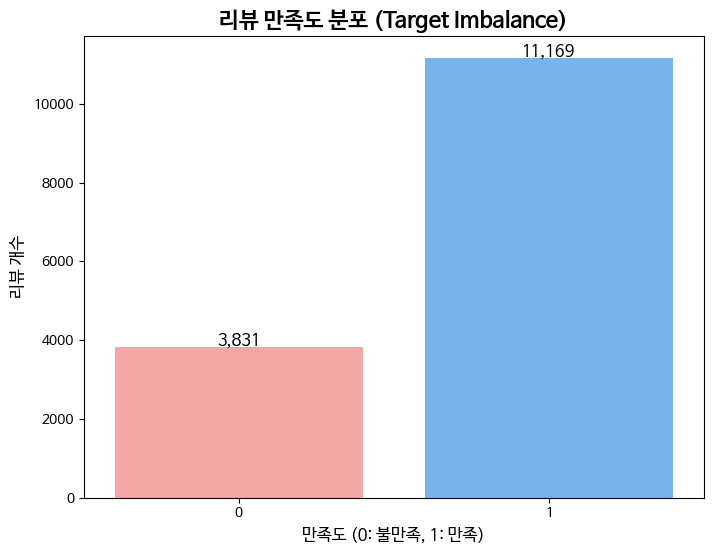

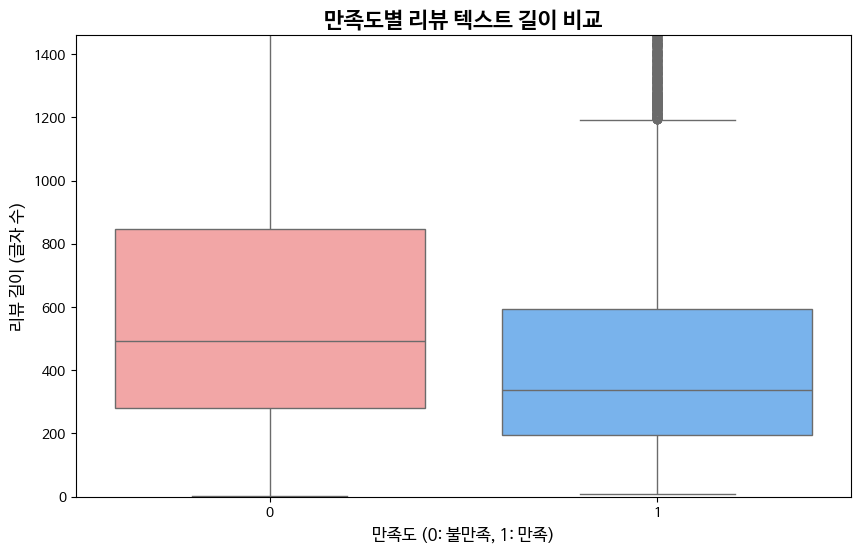

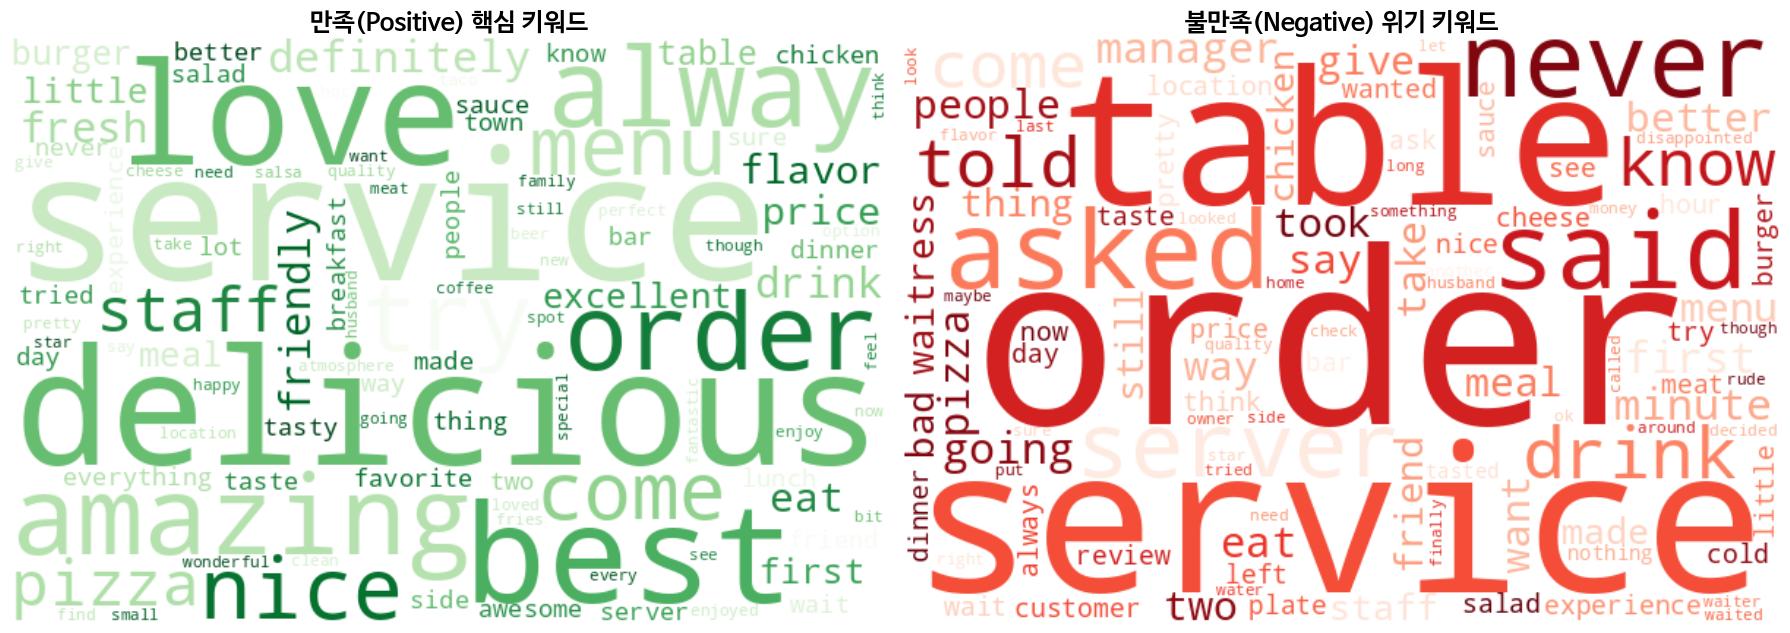

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

# ==========================================
# 1. 코랩 전용 한글 폰트 강제 지정
# ==========================================
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 (앞서 바로가기 만든 경로)
file_path = '/content/drive/MyDrive/ml_project/Team-6/data/interim/yelp_subset_tucson_15k.csv'
df = pd.read_csv(file_path)
df['text_length'] = df['text'].astype(str).apply(len)


# ==========================================
# 2. Target 분포도 (FutureWarning 해결 버전)
# ==========================================
plt.figure(figsize=(8, 6))

# x를 hue에 그대로 배정하고 legend=False를 주면 최신 버전 경고가 사라집니다.
ax = sns.countplot(data=df, x='is_positive', hue='is_positive', palette=['#ff9999', '#66b3ff'], legend=False)

plt.title('리뷰 만족도 분포 (Target Imbalance)', fontsize=16, fontweight='bold')
plt.xlabel('만족도 (0: 불만족, 1: 만족)', fontsize=12)
plt.ylabel('리뷰 개수', fontsize=12)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 50, f'{int(height):,}', ha='center', size=12)

plt.show()


# ==========================================
# 3. 텍스트 길이 분포 (FutureWarning 해결 버전)
# ==========================================
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_positive', y='text_length', hue='is_positive', palette=['#ff9999', '#66b3ff'], legend=False)

plt.title('만족도별 리뷰 텍스트 길이 비교', fontsize=16, fontweight='bold')
plt.xlabel('만족도 (0: 불만족, 1: 만족)', fontsize=12)
plt.ylabel('리뷰 길이 (글자 수)', fontsize=12)
plt.ylim(0, df['text_length'].quantile(0.95))

plt.show()


# ==========================================
# 4. 워드클라우드 (불용어 강화 버전)
# ==========================================
pos_text = " ".join(review for review in df[df['is_positive'] == 1]['text'].astype(str))
neg_text = " ".join(review for review in df[df['is_positive'] == 0]['text'].astype(str))

custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    "food", "place", "restaurant", "good", "great", "time", "one",
    "really", "even", "came", "went", "got", "make", "will", "go",
    "ordered", "us", "back", "much", "well", "Tucson", "tucson"
])

wc_pos = WordCloud(width=600, height=400, background_color='white', colormap='Greens', stopwords=custom_stopwords, max_words=100).generate(pos_text)
wc_neg = WordCloud(width=600, height=400, background_color='white', colormap='Reds', stopwords=custom_stopwords, max_words=100).generate(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('만족(Positive) 핵심 키워드', fontsize=18, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('불만족(Negative) 위기 키워드', fontsize=18, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

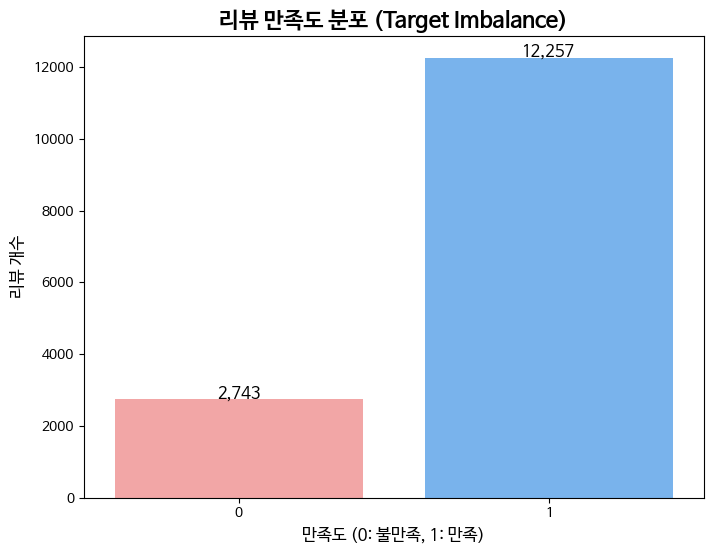

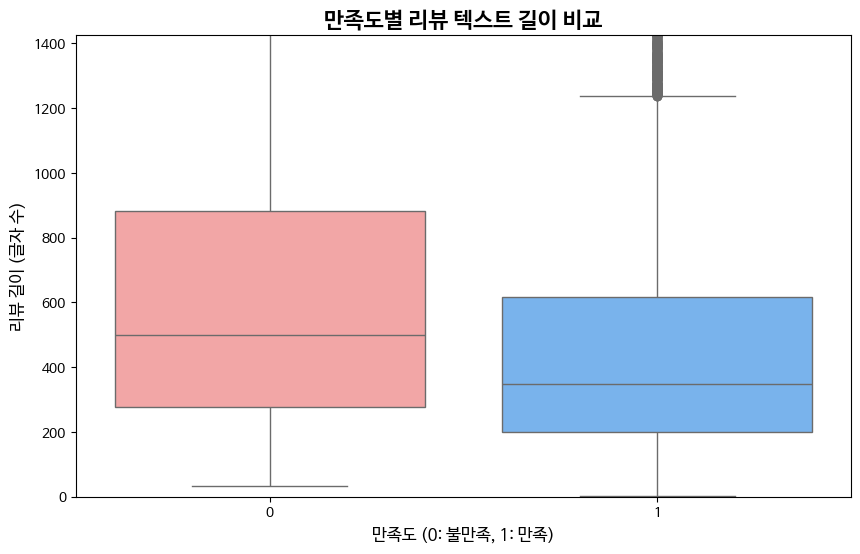

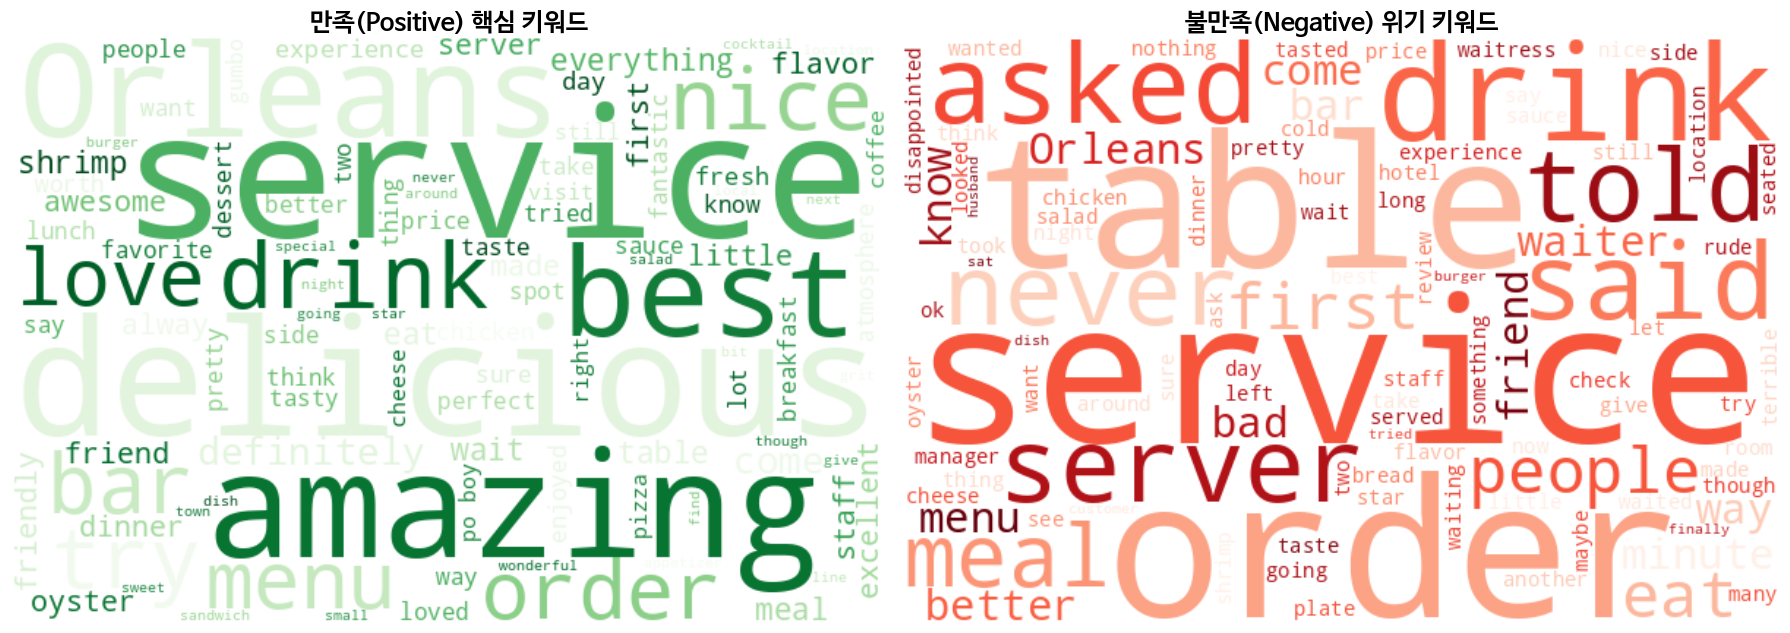

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

# ==========================================
# 1. 코랩 전용 한글 폰트 강제 지정
# ==========================================
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 (앞서 바로가기 만든 경로)
file_path = '/content/drive/MyDrive/ml_project/Team-6/data/interim/yelp_subset_new_orleans_15k.csv'
df = pd.read_csv(file_path)
df['text_length'] = df['text'].astype(str).apply(len)


# ==========================================
# 2. Target 분포도 (FutureWarning 해결 버전)
# ==========================================
plt.figure(figsize=(8, 6))

# x를 hue에 그대로 배정하고 legend=False를 주면 최신 버전 경고가 사라집니다.
ax = sns.countplot(data=df, x='is_positive', hue='is_positive', palette=['#ff9999', '#66b3ff'], legend=False)

plt.title('리뷰 만족도 분포 (Target Imbalance)', fontsize=16, fontweight='bold')
plt.xlabel('만족도 (0: 불만족, 1: 만족)', fontsize=12)
plt.ylabel('리뷰 개수', fontsize=12)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 50, f'{int(height):,}', ha='center', size=12)

plt.show()


# ==========================================
# 3. 텍스트 길이 분포 (FutureWarning 해결 버전)
# ==========================================
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_positive', y='text_length', hue='is_positive', palette=['#ff9999', '#66b3ff'], legend=False)

plt.title('만족도별 리뷰 텍스트 길이 비교', fontsize=16, fontweight='bold')
plt.xlabel('만족도 (0: 불만족, 1: 만족)', fontsize=12)
plt.ylabel('리뷰 길이 (글자 수)', fontsize=12)
plt.ylim(0, df['text_length'].quantile(0.95))

plt.show()


# ==========================================
# 4. 워드클라우드 (불용어 강화 버전)
# ==========================================
pos_text = " ".join(review for review in df[df['is_positive'] == 1]['text'].astype(str))
neg_text = " ".join(review for review in df[df['is_positive'] == 0]['text'].astype(str))

custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    "food", "place", "restaurant", "good", "great", "time", "one",
    "really", "even", "came", "went", "got", "make", "will", "go",
    "ordered", "us", "back", "much", "well","New Orlean", "New Orleans", "NOLA", "nola", "new orleans", "New", "Orlean"
])

wc_pos = WordCloud(width=600, height=400, background_color='white', colormap='Greens', stopwords=custom_stopwords, max_words=100).generate(pos_text)
wc_neg = WordCloud(width=600, height=400, background_color='white', colormap='Reds', stopwords=custom_stopwords, max_words=100).generate(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('만족(Positive) 핵심 키워드', fontsize=18, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('불만족(Negative) 위기 키워드', fontsize=18, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()